## Cldn4 Article Figs
March 10th 2026
by e_bruli

In [2]:
#If not loaded already:
!pip install scanpy
!pip install pandas
!pip install openpyxl
!pip install matplotlib
!pip install pydeseq2
import scanpy as sc
import pandas as pd
import random
import numpy as np
import matplotlib as plt
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import gc 
import ctypes
gc.collect()
libc = ctypes.CDLL("libc.so.6") # clearing cache 
libc.malloc_trim(0)

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx

1

In [3]:
#LuCa dataset
adata = sc.read_h5ad('/home/biolab/Projects/DesCARTes_wd/data/202603_luca.h5ad')
adata

AnnData object with n_obs × n_vars = 1283972 × 17764
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'cell_type_neutro', 'cell_type_neutro_coarse', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'm

In [4]:
#change ensmble id to gene name:
adata.var_names = adata.var['feature_name']
adata.var_names_make_unique()

# Verify
print("CLDN4" in adata.var_names)  # should print True

True


/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['A1BG', 'A1BG-AS1', 'A2M', 'A2M-AS1', 'A2ML1']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


In [5]:
adata.var

,is_highly_variable,mito,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
feature_name,,,,,,,,,,,,
A1BG,True,False,86866,2.527138,90.681054,2355657.0,False,A1BG,NCBITaxon:9606,gene,2301,protein_coding
A1BG-AS1,True,False,12257,0.369194,98.685074,344142.0,False,A1BG-AS1,NCBITaxon:9606,gene,1667,lncRNA
A2M,True,False,122241,22.579874,86.886039,21047694.0,False,A2M,NCBITaxon:9606,gene,590,protein_coding
A2M-AS1,False,False,8827,0.172223,99.053043,160537.0,False,A2M-AS1,NCBITaxon:9606,gene,1809,lncRNA
A2ML1,True,False,5096,0.038011,99.453303,35432.0,False,A2ML1,NCBITaxon:9606,gene,592,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,False,False,43291,0.442399,95.355760,412380.0,False,ZXDC,NCBITaxon:9606,gene,3006,protein_coding
ZYG11A,False,False,3517,0.009742,99.622698,9081.0,False,ZYG11A,NCBITaxon:9606,gene,4193,protein_coding
ZYG11B,False,False,71512,0.275276,92.328224,256597.0,False,ZYG11B,NCBITaxon:9606,gene,5218,protein_coding


In [ ]:
## My Original code

def make_pseudobulk(adata, sample_colname, cell_type_colname, metacols):
    '''
    To create an an data with pseudo-bulk gene expression profiles for the samples and cell_types given.
    The function also carries metadata columns from the obs. metacols: as a list of col names.
    This is how to use:
        ps_adata = make_pseudobulk(hlca, sample_colname = 'sample', cell_type_colname = 'cell_type', metacols= ['patient', 'disease', 'tissue', 'study', 'sex'])
    '''
    ps_list = []
    for s in adata.obs[sample_colname].unique():
        adata_sub = adata[adata.obs[sample_colname] == s]
        
        for ct in adata_sub.obs[cell_type_colname].unique():
            adata_sub_ct = adata_sub[adata_sub.obs[cell_type_colname] == ct]
            
            adata_rep = sc.AnnData(X = adata_sub_ct.X.sum(axis = 0),
                                   var = adata_sub_ct.var[[]])
            samp_name=adata_sub.obs[sample_colname].iloc[0]
            cell= adata_sub_ct.obs[cell_type_colname].iloc[0]
            adata_rep.obs_names = [f"{samp_name}{cell}"]
            adata_rep.obs[cell_type_colname] = adata_sub_ct.obs[cell_type_colname].iloc[0]
            adata_rep.obs[metacols] = adata_sub_ct.obs[metacols].iloc[0]
            ps_list.append(adata_rep)

    ps_adata = sc.concat(ps_list)
    
    return ps_adata



def savePBdata(adata, filename):
    #save the count matrix as df
    counts = adata.DataFrame(adata.X, columns = adata.var_names)
    counts = counts.astype(int, errors='ignore')
    #To get rid off all the 0s in count matrix (to prevent problems)
    counts=counts+1
    #save the obs as colData
    

 #Create a pseudo-bulk of LuCa-extended.

ps_adata_luca = make_pseudobulk(adata, sample_colname = 'sample', cell_type_colname = 'cell_type', metacols= ['donor_id', 'disease', 'tissue', 'study', 'sex', 'age', 'uicc_stage', 'tumor_stage']) 




#save pseudobulk object
#convert numpy matrix to numpy array:
ps_adata_luca.X = np.asarray(ps_adata_luca)
ps_adata_luca.write_h5ad('luca_ps_profile.h5ad')

CLDN4 in adata.var_names: True
CLDN4 in adata.raw.var_names: True
Pipeline 1 — 1,014,841 cells, 434 samples
origin
tumor_primary       585138
normal_adjacent     325538
tumor_metastasis     71272
normal               32893
Name: count, dtype: int64


/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.ma


Pseudobulk P1 shape: (7381, 17764)


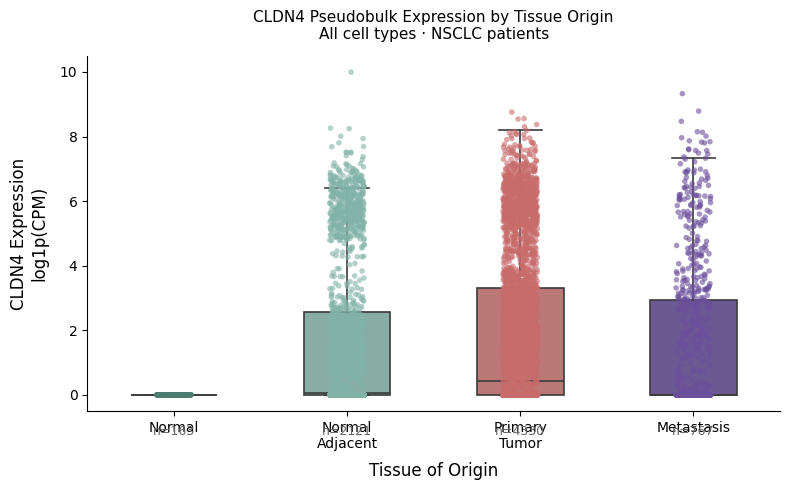

Saved: cldn4_by_origin.pdf / .png


In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse


import os

# ── Define output directory ────────────────────────────────────────
OUT_DIR = "/home/ebrukocakaya/202603_cldn4_figs"  # change this to your desired path
os.makedirs(OUT_DIR, exist_ok=True) # creates the folder if it doesn't exist

# ══════════════════════════════════════════════════════════════════════════════
# PSEUDOBULK FUNCTION cleaned up with Claude
# ══════════════════════════════════════════════════════════════════════════════

def make_pseudobulk(adata, sample_colname, cell_type_colname, metacols):
    '''
    Creates pseudobulk AnnData by summing RAW counts per sample x cell_type.
    Uses adata.raw.X (raw counts) so downstream CPM + log1p normalization is valid.
    Each resulting row = one sample x cell_type combination.
    '''
    assert adata.raw is not None, \
        "adata.raw is None — raw counts not stored. Cannot use Option A."

    # Build a var DataFrame from raw (raw may contain more genes than adata.X)
    raw_var = pd.DataFrame(index=adata.raw.var_names)

    ps_list = []
    for s in adata.obs[sample_colname].unique():
        adata_sub = adata[adata.obs[sample_colname] == s]
        for ct in adata_sub.obs[cell_type_colname].unique():
            adata_sub_ct = adata_sub[adata_sub.obs[cell_type_colname] == ct]

            # Use raw counts — correct for pseudobulk aggregation
            X_sum = adata_sub_ct.raw.X.sum(axis=0)
            if issparse(X_sum):
                X_sum = X_sum.toarray()

            adata_rep = sc.AnnData(
                X   = X_sum,
                var = raw_var          # use raw var so gene names align
            )
            samp_name = adata_sub.obs[sample_colname].iloc[0]
            cell      = adata_sub_ct.obs[cell_type_colname].iloc[0]

            adata_rep.obs_names           = [f"{samp_name}_{cell}"]
            adata_rep.obs[cell_type_colname] = cell
            adata_rep.obs[metacols]       = adata_sub_ct.obs[metacols].iloc[0].values

            ps_list.append(adata_rep)

    return sc.concat(ps_list)


def extract_gene(ps_adata, gene):
    '''Extract a single gene's expression from pseudobulk AnnData into obs.
    Note: var_names come from adata.raw — must use gene symbols (feature_name).
    '''
    assert gene in ps_adata.var_names, \
        f"{gene} not found in var_names — check that adata.raw.var_names uses gene symbols!"
    idx  = ps_adata.var_names.get_loc(gene)
    expr = ps_adata.X[:, idx]
    if issparse(expr):
        expr = expr.toarray().flatten()
    ps_adata.obs[f"{gene}_expr"] = np.array(expr).flatten()
    return ps_adata


# ══════════════════════════════════════════════════════════════════════════════
# SHARED SETUP
# ══════════════════════════════════════════════════════════════════════════════

# Swap var_names to gene symbols if not already done
if "CLDN4" not in adata.var_names:
    adata.var_names = adata.var["feature_name"]
    adata.var_names_make_unique()

# ++ Do the same for adata.raw ++
if "CLDN4" not in adata.raw.var_names:
    raw_adata = adata.raw.to_adata()
    raw_adata.var_names = raw_adata.var["feature_name"]
    raw_adata.var_names_make_unique()
    adata.raw = raw_adata

print("CLDN4 in adata.var_names:", "CLDN4" in adata.var_names)
print("CLDN4 in adata.raw.var_names:", "CLDN4" in adata.raw.var_names)

# Remap disease labels (COPD → NaN → excluded by masks)
disease_map = {
    "lung adenocarcinoma"          : "NSCLC",
    "squamous cell lung carcinoma" : "NSCLC",
    "non-small cell lung carcinoma": "NSCLC",
    "normal"                       : "Normal",
}
adata.obs["disease_grouped"] = adata.obs["disease"].map(disease_map)


# ══════════════════════════════════════════════════════════════════════════════
# PIPELINE 1 — ALL CELL TYPES FROM CANCER PATIENTS → PLOT BY ORIGIN
# ══════════════════════════════════════════════════════════════════════════════

# ── 1a. Subset: all cells from NSCLC patients, exclude NaN origin ─────────
mask_p1 = (
    (adata.obs["disease_grouped"] == "NSCLC") &
    (adata.obs["origin"].isin(["normal", "normal_adjacent",
                                "tumor_primary", "tumor_metastasis"]))
)
adata_p1 = adata[mask_p1].copy()
print(f"Pipeline 1 — {adata_p1.n_obs:,} cells, "
      f"{adata_p1.obs['sample'].nunique()} samples")
print(adata_p1.obs["origin"].value_counts())

# ── 1b. Pseudobulk per sample × cell_type_major ───────────────────────────
ps1 = make_pseudobulk(
    adata_p1,
    sample_colname    = "sample",
    cell_type_colname = "cell_type_major",
    metacols          = ["disease_grouped", "origin"]
)
print(f"\nPseudobulk P1 shape: {ps1.shape}")

# ── 1c. Normalize ─────────────────────────────────────────────────────────
sc.pp.normalize_total(ps1, target_sum=1e6)  # CPM
sc.pp.log1p(ps1)                            # log1p(CPM)

# ── 1d. Extract CLDN4 ──────────────────────────────────────────────────────
ps1 = extract_gene(ps1, "CLDN4")

# ── 1e. Plot ───────────────────────────────────────────────────────────────
origin_order  = ["normal", "normal_adjacent", "tumor_primary", "tumor_metastasis"]
origin_colors = {
    "normal"            : "#4a7c6f",
    "normal_adjacent"   : "#82b3a8",
    "tumor_primary"     : "#c86b6b",
    "tumor_metastasis"  : "#6b4f9b",
}
palette1 = [origin_colors[o] for o in origin_order]

fig1, ax1 = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data      = ps1.obs,
    x         = "origin",
    y         = "CLDN4_expr",
    order     = origin_order,
    palette   = palette1,
    width     = 0.5,
    linewidth = 1.2,
    fliersize = 0,
    ax        = ax1,
)
sns.stripplot(
    data      = ps1.obs,
    x         = "origin",
    y         = "CLDN4_expr",
    order     = origin_order,
    palette   = palette1,
    size      = 4,
    alpha     = 0.6,
    jitter    = True,
    ax        = ax1,
)

# Sample size annotations
ymin1, ymax1 = ax1.get_ylim()
for i, org in enumerate(origin_order):
    n = (ps1.obs["origin"] == org).sum()
    ax1.text(i, ymin1 - 0.04*(ymax1-ymin1),
             f"n={n}", ha="center", va="top", fontsize=9, color="#666666")

ax1.set_xticklabels(["Normal", "Normal\nAdjacent", "Primary\nTumor", "Metastasis"],
                     fontsize=10)
ax1.set_xlabel("Tissue of Origin", fontsize=12, labelpad=8)
ax1.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
ax1.set_title("CLDN4 Pseudobulk Expression by Tissue Origin\nAll cell types · NSCLC patients",
              fontsize=11, pad=12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_origin.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_origin.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cldn4_by_origin.pdf / .png")




Pipeline 2 — 89,242 tumor cells, 247 samples
uicc_stage
III or IV    32446
IV           18349
I            16129
III          14486
II            7832
Name: count, dtype: int64


/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.ma


Pseudobulk P2 shape: (247, 17764)

Unique stage labels: ['III', 'I', 'II', 'IV', 'III or IV']


<Figure size 640x480 with 0 Axes>

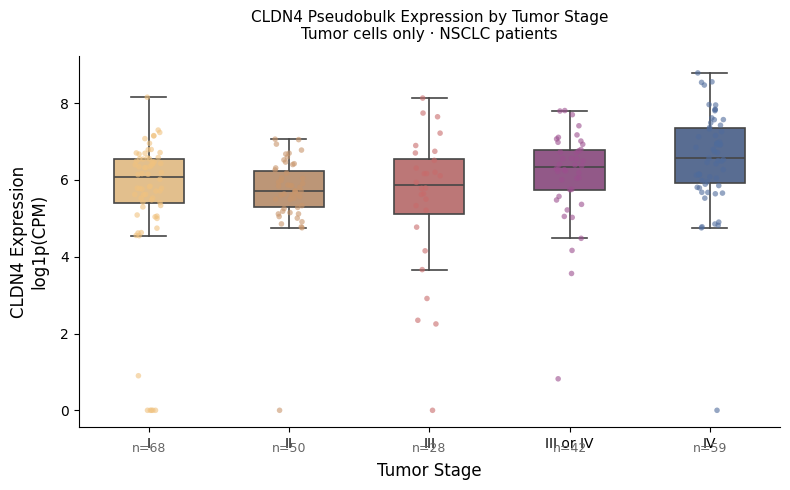

Saved: cldn4_by_stage.pdf / .png


In [11]:
OUT_DIR = "/home/ebrukocakaya/202603_cldn4_figs"   # change this to your desired path
os.makedirs(OUT_DIR, exist_ok=True) # creates the folder if it doesn't exist

plt.tight_layout()
# ══════════════════════════════════════════════════════════════════════════════
# PIPELINE 2 — TUMOR CELLS ONLY → PLOT BY TUMOR STAGE
# ══════════════════════════════════════════════════════════════════════════════

# ── 2a. Subset: Tumor cells from NSCLC patients with known stage ──────────
mask_p2 = (
    (adata.obs["disease_grouped"] == "NSCLC")              &
    (adata.obs["cell_type_major"] == "Tumor cells")        &
    (adata.obs["origin"].isin(["tumor_primary",
                                "tumor_metastasis"]))      &
    (adata.obs["uicc_stage"].notna())
)
adata_p2 = adata[mask_p2].copy()
print(f"\nPipeline 2 — {adata_p2.n_obs:,} tumor cells, "
      f"{adata_p2.obs['sample'].nunique()} samples")
print(adata_p2.obs["uicc_stage"].value_counts())

# ── 2b. Pseudobulk per sample (only Tumor cells → one row per sample) ─────
ps2 = make_pseudobulk(
    adata_p2,
    sample_colname    = "sample",
    cell_type_colname = "cell_type_major",
    metacols          = ["disease_grouped", "uicc_stage", "origin"]
)
print(f"\nPseudobulk P2 shape: {ps2.shape}")

# ── 2c. Normalize ─────────────────────────────────────────────────────────
sc.pp.normalize_total(ps2, target_sum=1e6)
sc.pp.log1p(ps2)

# ── 2d. Extract CLDN4 ──────────────────────────────────────────────────────
ps2 = extract_gene(ps2, "CLDN4")

# ── 2e. Order stages ───────────────────────────────────────────────────────
# !! Print unique values and adjust stage_order if labels differ !!
print("\nUnique stage labels:", ps2.obs["uicc_stage"].unique().tolist())

stage_order  = ["I", "II", "III", "III or IV", "IV"]   # adjust if needed
stage_order  = [s for s in stage_order if s in ps2.obs["uicc_stage"].values]
stage_colors = {
    "I"        : "#f0c27f",
    "II"       : "#c8956b",
    "III"      : "#c86b6b",
    "III or IV": "#9b4f8e",
    "IV"       : "#4f6b9b",
}
palette2 = [stage_colors.get(s, "#888888") for s in stage_order]

df2 = ps2.obs[["uicc_stage", "CLDN4_expr"]].copy()
df2["uicc_stage"] = pd.Categorical(
    df2["uicc_stage"], categories=stage_order, ordered=True
)
df2 = df2[df2["uicc_stage"].notna()].copy()

# ── 2f. Plot ───────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data      = df2,
    x         = "uicc_stage",
    y         = "CLDN4_expr",
    order     = stage_order,
    palette   = palette2,
    width     = 0.5,
    linewidth = 1.2,
    fliersize = 0,
    ax        = ax2,
)
sns.stripplot(
    data      = df2,
    x         = "uicc_stage",
    y         = "CLDN4_expr",
    order     = stage_order,
    palette   = palette2,
    size      = 4,
    alpha     = 0.6,
    jitter    = True,
    ax        = ax2,
)

# Sample size annotations
ymin2, ymax2 = ax2.get_ylim()
for i, stage in enumerate(stage_order):
    n = (df2["uicc_stage"] == stage).sum()
    ax2.text(i, ymin2 - 0.04*(ymax2-ymin2),
             f"n={n}", ha="center", va="top", fontsize=9, color="#666666")

ax2.set_xlabel("Tumor Stage", fontsize=12, labelpad=8)
ax2.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
ax2.set_title("CLDN4 Pseudobulk Expression by Tumor Stage\nTumor cells only · NSCLC patients",
              fontsize=11, pad=12)
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cldn4_by_stage.pdf / .png")

In [6]:
adata

AnnData object with n_obs × n_vars = 1283972 × 17764
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'cell_type_neutro', 'cell_type_neutro_coarse', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'm

CLDN4 in adata.var_names: True
CLDN4 in adata.raw.var_names: True

Subset: 1,014,841 cells · 434 samples
origin
tumor_primary       585138
normal_adjacent     325538
tumor_metastasis     71272
normal               32893
Name: count, dtype: int64
cell_type_major
T cell CD4               181767
T cell CD8               139837
Tumor cells               90010
Macrophage                89074
Macrophage alveolar       84892
B cell                    63455
NK cell                   55875
Monocyte                  54345
T cell regulatory         38583
Endothelial cell          33379
Plasma cell               32318
transitional club/AT2     23928
cDC2                      23459
Neutrophils               19158
Alveolar cell type 2      17050
other                     16157
Mast cell                 15261
Stromal                   15144
Ciliated                   6627
pDC                        4661
Alveolar cell type 1       3944
cDC1                       2393
DC mature                  1871
Cl

/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.ma


Pseudobulk shape: (7381, 17764)
                                              cell_type_major disease_grouped  \
Chen_Zhang_2020_NSCLC-10_T cell CD8                T cell CD8           NSCLC   
Chen_Zhang_2020_NSCLC-10_Tumor cells              Tumor cells           NSCLC   
Chen_Zhang_2020_NSCLC-10_B cell                        B cell           NSCLC   
Chen_Zhang_2020_NSCLC-10_Plasma cell              Plasma cell           NSCLC   
Chen_Zhang_2020_NSCLC-10_T cell regulatory  T cell regulatory           NSCLC   

                                                   origin uicc_stage  
Chen_Zhang_2020_NSCLC-10_T cell CD8         tumor_primary        III  
Chen_Zhang_2020_NSCLC-10_Tumor cells        tumor_primary        III  
Chen_Zhang_2020_NSCLC-10_B cell             tumor_primary        III  
Chen_Zhang_2020_NSCLC-10_Plasma cell        tumor_primary        III  
Chen_Zhang_2020_NSCLC-10_T cell regulatory  tumor_primary        III  
Normalization done.
                                  

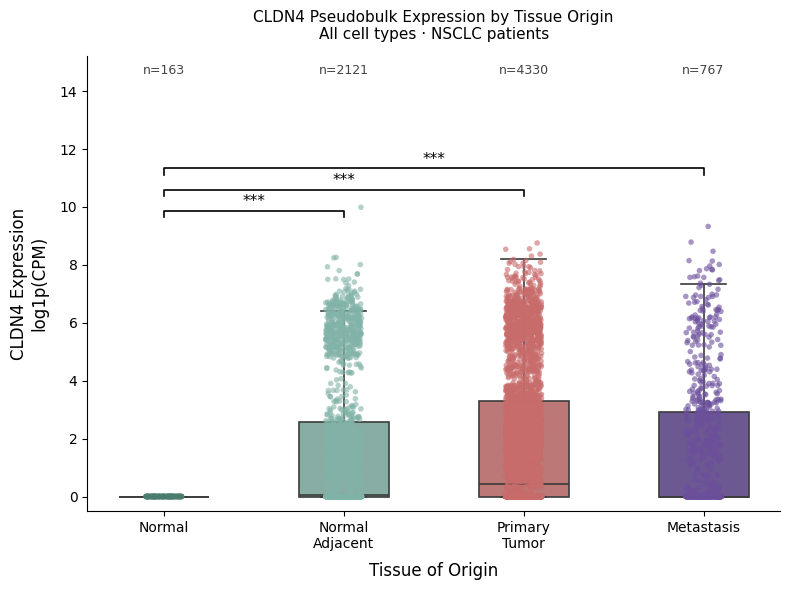

Saved: cldn4_by_origin.pdf / .png

Unique uicc_stage labels: ['III', 'I', 'II', 'IV', 'III or IV']

Plot 2 significance (vs Stage I):
  I vs II: p=2.08e-01 ns
  I vs III: p=7.41e-01 ns
  I vs III or IV: p=7.14e-03 **
  I vs IV: p=2.70e-06 ***


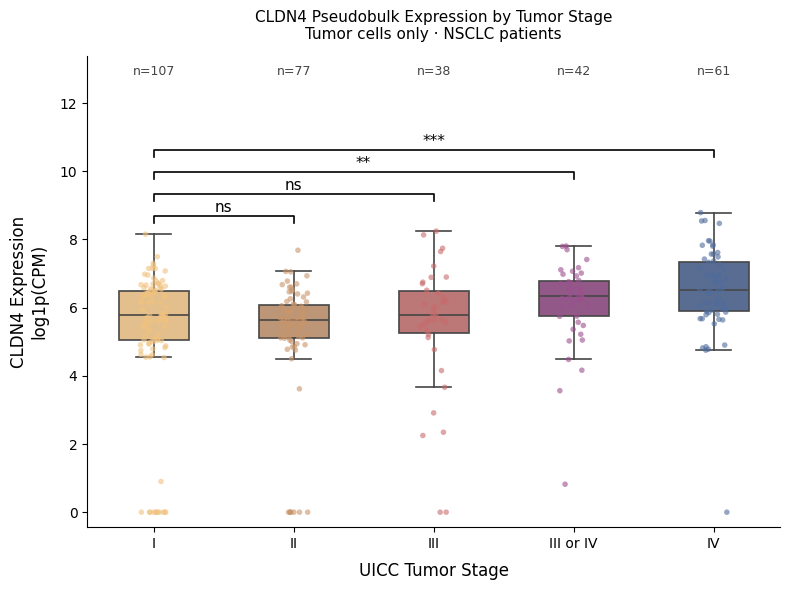

Saved: cldn4_by_stage.pdf / .png


In [9]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.sparse import issparse

# ══════════════════════════════════════════════════════════════════════════════
# OUTPUT DIRECTORY
# ══════════════════════════════════════════════════════════════════════════════

OUT_DIR = "/home/ebrukocakaya/202603_cldn4_figs/fig_2/"   # !! change this !!
os.makedirs(OUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def make_pseudobulk(adata, sample_colname, cell_type_colname, metacols):
    '''
    Creates pseudobulk AnnData by summing RAW counts per sample × cell_type.
    Uses adata.raw.X so downstream CPM + log1p normalization is valid.
    Each row = one sample × cell_type combination.
    '''
    assert adata.raw is not None, \
        "adata.raw is None — raw counts not stored!"

    raw_var = pd.DataFrame(index=adata.raw.var_names)
    ps_list = []

    for s in adata.obs[sample_colname].unique():
        adata_sub = adata[adata.obs[sample_colname] == s]
        for ct in adata_sub.obs[cell_type_colname].unique():
            adata_sub_ct = adata_sub[adata_sub.obs[cell_type_colname] == ct]

            X_sum = adata_sub_ct.raw.X.sum(axis=0)
            if issparse(X_sum):
                X_sum = X_sum.toarray()

            adata_rep = sc.AnnData(X=X_sum, var=raw_var)

            samp_name = adata_sub.obs[sample_colname].iloc[0]
            cell      = adata_sub_ct.obs[cell_type_colname].iloc[0]

            adata_rep.obs_names              = [f"{samp_name}_{cell}"]
            adata_rep.obs[cell_type_colname] = cell
            adata_rep.obs[metacols]          = adata_sub_ct.obs[metacols].iloc[0].values

            ps_list.append(adata_rep)

    return sc.concat(ps_list)


def extract_gene(ps_adata, gene):
    '''Extract a single gene's expression from pseudobulk AnnData into obs.'''
    assert gene in ps_adata.var_names, \
        f"{gene} not found in var_names — check adata.raw.var_names uses gene symbols!"
    idx  = ps_adata.var_names.get_loc(gene)
    expr = ps_adata.X[:, idx]
    if issparse(expr):
        expr = expr.toarray().flatten()
    ps_adata.obs[f"{gene}_expr"] = np.array(expr).flatten()
    return ps_adata


def pval_to_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:           return "ns"


def add_significance(ax, group_order, group_col, expr_col, df,
                     ref_group, ymax, step_size=0.07):
    '''
    Draws significance brackets comparing ref_group vs all other groups.
    Uses Mann-Whitney U (Wilcoxon rank-sum) test.
    '''
    ref_data = df[df[group_col] == ref_group][expr_col].dropna().values
    ref_x    = group_order.index(ref_group)
    comparisons = [g for g in group_order if g != ref_group]

    for step, comp in enumerate(comparisons):
        comp_data = df[df[group_col] == comp][expr_col].dropna().values
        _, p      = stats.mannwhitneyu(ref_data, comp_data, alternative="two-sided")
        stars     = pval_to_stars(p)
        comp_x    = group_order.index(comp)
        y_line    = ymax * (0.92 + step * step_size)

        # Bracket
        ax.plot([ref_x, ref_x, comp_x, comp_x],
                [y_line, y_line + ymax*0.02,
                 y_line + ymax*0.02, y_line],
                lw=1.2, color="black")
        ax.text((ref_x + comp_x) / 2, y_line + ymax*0.025,
                stars, ha="center", va="bottom", fontsize=11)

        print(f"  {ref_group} vs {comp}: p={p:.2e} {stars}")


# ══════════════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════════════

# Swap var_names to gene symbols
if "CLDN4" not in adata.var_names:
    adata.var_names = adata.var["feature_name"]
    adata.var_names_make_unique()

# Swap raw var_names too
if "CLDN4" not in adata.raw.var_names:
    raw_adata = adata.raw.to_adata()
    raw_adata.var_names = raw_adata.var["feature_name"]
    raw_adata.var_names_make_unique()
    adata.raw = raw_adata

print("CLDN4 in adata.var_names:", "CLDN4" in adata.var_names)
print("CLDN4 in adata.raw.var_names:", "CLDN4" in adata.raw.var_names)

# Remap disease labels — COPD → NaN → excluded by mask
disease_map = {
    "lung adenocarcinoma"          : "NSCLC",
    "squamous cell lung carcinoma" : "NSCLC",
    "non-small cell lung carcinoma": "NSCLC",
}
adata.obs["disease_grouped"] = adata.obs["disease"].map(disease_map)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — SUBSET: ALL CELLS FROM NSCLC PATIENTS WITH KNOWN ORIGIN
# ══════════════════════════════════════════════════════════════════════════════

mask = (
    (adata.obs["disease_grouped"] == "NSCLC") &
    (adata.obs["origin"].isin(["normal", "normal_adjacent",
                                "tumor_primary", "tumor_metastasis"]))
)
adata_nsclc = adata[mask].copy()

print(f"\nSubset: {adata_nsclc.n_obs:,} cells · "
      f"{adata_nsclc.obs['sample'].nunique()} samples")
print(adata_nsclc.obs["origin"].value_counts())
print(adata_nsclc.obs["cell_type_major"].value_counts())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — ONE PSEUDOBULK: per sample × cell_type_major
# ══════════════════════════════════════════════════════════════════════════════

ps_adata = make_pseudobulk(
    adata_nsclc,
    sample_colname    = "sample",
    cell_type_colname = "cell_type_major",
    metacols          = ["disease_grouped", "origin", "uicc_stage"]
)
print(f"\nPseudobulk shape: {ps_adata.shape}")
print(ps_adata.obs.head())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — NORMALIZE (once, on the full pseudobulk)
# ══════════════════════════════════════════════════════════════════════════════

sc.pp.normalize_total(ps_adata, target_sum=1e6)  # CPM
sc.pp.log1p(ps_adata)                            # log1p(CPM)
print("Normalization done.")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — EXTRACT CLDN4
# ══════════════════════════════════════════════════════════════════════════════

ps_adata = extract_gene(ps_adata, "CLDN4")
print(ps_adata.obs[["cell_type_major", "origin", "uicc_stage", "CLDN4_expr"]].head(10))

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — CLDN4 BY TISSUE ORIGIN (all cell types)
# ══════════════════════════════════════════════════════════════════════════════

origin_order  = ["normal", "normal_adjacent", "tumor_primary", "tumor_metastasis"]
origin_labels = ["Normal", "Normal\nAdjacent", "Primary\nTumor", "Metastasis"]
origin_colors = {
    "normal"           : "#4a7c6f",
    "normal_adjacent"  : "#82b3a8",
    "tumor_primary"    : "#c86b6b",
    "tumor_metastasis" : "#6b4f9b",
}
palette1 = [origin_colors[o] for o in origin_order]

# Filter only rows with valid origin
df1 = ps_adata.obs[ps_adata.obs["origin"].isin(origin_order)].copy()

fig1, ax1 = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df1, x="origin", y="CLDN4_expr",
    order=origin_order, palette=palette1,
    width=0.5, linewidth=1.2, fliersize=0, ax=ax1,
)
sns.stripplot(
    data=df1, x="origin", y="CLDN4_expr",
    order=origin_order, palette=palette1,
    size=4, alpha=0.6, jitter=True, ax=ax1,
)

# n= annotations above boxes
ymin1, ymax1 = ax1.get_ylim()
for i, org in enumerate(origin_order):
    n = (df1["origin"] == org).sum()
    ax1.text(i, ymax1 * 1.38,  # ← pushed above brackets
             f"n={n}", ha="center", va="bottom", fontsize=9, color="#444444")

# Significance vs Normal
print("\nPlot 1 significance (vs normal):")
add_significance(ax1, origin_order, "origin", "CLDN4_expr",
                 df1, ref_group="normal", ymax=ymax1)

# Extend y-axis for brackets
ax1.set_ylim(ymin1, ymax1 * 1.45)
ax1.set_xticks(range(len(origin_order)))
ax1.set_xticklabels(origin_labels, fontsize=10)
ax1.set_xlabel("Tissue of Origin", fontsize=12, labelpad=8)
ax1.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
ax1.set_title("CLDN4 Pseudobulk Expression by Tissue Origin\nAll cell types · NSCLC patients",
              fontsize=11, pad=12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_origin.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_origin.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cldn4_by_origin.pdf / .png")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — CLDN4 BY TUMOR STAGE (Tumor cells only)
# ══════════════════════════════════════════════════════════════════════════════

# Filter: Tumor cells only + known uicc_stage
df2 = ps_adata.obs[
    (ps_adata.obs["cell_type_major"] == "Tumor cells") &
    (ps_adata.obs["uicc_stage"].notna())
].copy()

# !! Check stage labels and adjust stage_order if needed !!
print("\nUnique uicc_stage labels:", df2["uicc_stage"].unique().tolist())

stage_order = ["I", "II", "III", "III or IV", "IV"]   # adjust if needed
stage_order = [s for s in stage_order if s in df2["uicc_stage"].values]

df2["uicc_stage"] = pd.Categorical(df2["uicc_stage"],
                                    categories=stage_order, ordered=True)
df2 = df2[df2["uicc_stage"].notna()].copy()

stage_colors = {
    "I"        : "#f0c27f",
    "II"       : "#c8956b",
    "III"      : "#c86b6b",
    "III or IV": "#9b4f8e",
    "IV"       : "#4f6b9b",
}
palette2 = [stage_colors.get(s, "#888888") for s in stage_order]

fig2, ax2 = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df2, x="uicc_stage", y="CLDN4_expr",
    order=stage_order, palette=palette2,
    width=0.5, linewidth=1.2, fliersize=0, ax=ax2,
)
sns.stripplot(
    data=df2, x="uicc_stage", y="CLDN4_expr",
    order=stage_order, palette=palette2,
    size=4, alpha=0.6, jitter=True, ax=ax2,
)

# n= annotations above boxes
ymin2, ymax2 = ax2.get_ylim()
for i, stage in enumerate(stage_order):
    n = (df2["uicc_stage"] == stage).sum()
    ax2.text(i, ymax2 * 1.38,  # ← pushed above brackets
             f"n={n}", ha="center", va="bottom", fontsize=9, color="#444444")

# Significance vs Stage I
print("\nPlot 2 significance (vs Stage I):")
add_significance(ax2, stage_order, "uicc_stage", "CLDN4_expr",
                 df2, ref_group=stage_order[0], ymax=ymax2)

# Extend y-axis for brackets
ax2.set_ylim(ymin2, ymax2 * 1.45)
ax2.set_xlabel("UICC Tumor Stage", fontsize=12, labelpad=8)
ax2.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
ax2.set_title("CLDN4 Pseudobulk Expression by Tumor Stage\nTumor cells only · NSCLC patients",
              fontsize=11, pad=12)
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cldn4_by_stage.pdf / .png")


Plot 3 — unique uicc_stage labels: ['III', 'I', 'II', 'IV', 'III or IV']

Plot 3 significance (vs Stage I):
  I vs II: p=3.71e-01 ns
  I vs III: p=7.20e-03 **
  I vs III or IV: p=6.64e-03 **
  I vs IV: p=1.18e-02 *


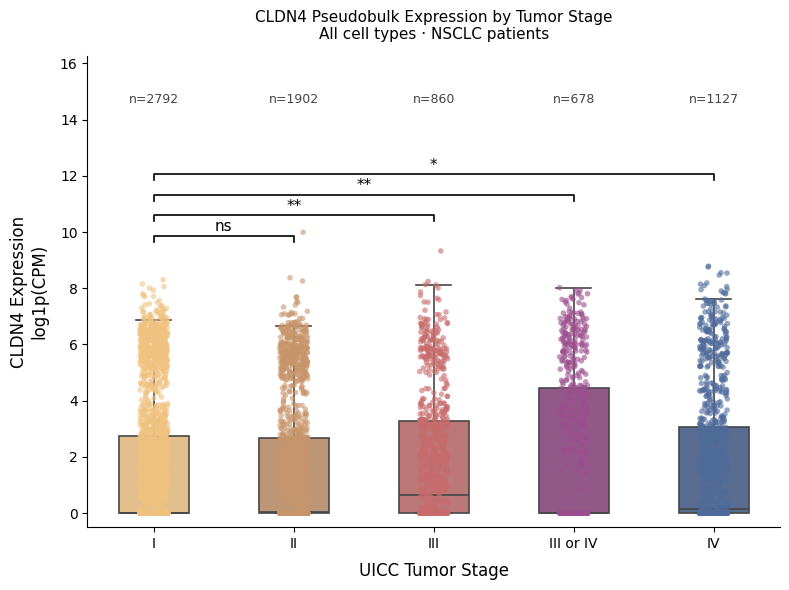

Saved: cldn4_by_stage_allcells.pdf / .png


In [8]:
# ══════════════════════════════════════════════════════════════════
# PLOT 3 — CLDN4 BY TUMOR STAGE (ALL cell types)
# ══════════════════════════════════════════════════════════════════

# Filter: all cell types + known uicc_stage
df3 = ps_adata.obs[
    ps_adata.obs["uicc_stage"].notna()
].copy()

print("\nPlot 3 — unique uicc_stage labels:", df3["uicc_stage"].unique().tolist())

# Reuse same stage_order and palette from Plot 2
df3["uicc_stage"] = pd.Categorical(df3["uicc_stage"],
                                    categories=stage_order, ordered=True)
df3 = df3[df3["uicc_stage"].notna()].copy()

fig3, ax3 = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df3, x="uicc_stage", y="CLDN4_expr",
    order=stage_order, palette=palette2,
    width=0.5, linewidth=1.2, fliersize=0, ax=ax3,
)
sns.stripplot(
    data=df3, x="uicc_stage", y="CLDN4_expr",
    order=stage_order, palette=palette2,
    size=4, alpha=0.6, jitter=True, ax=ax3,
)

# n= annotations
ymin3, ymax3 = ax3.get_ylim()
for i, stage in enumerate(stage_order):
    n = (df3["uicc_stage"] == stage).sum()
    ax3.text(i, ymax3 * 1.38,
             f"n={n}", ha="center", va="bottom", fontsize=9, color="#444444")

# Significance vs Stage I
print("\nPlot 3 significance (vs Stage I):")
add_significance(ax3, stage_order, "uicc_stage", "CLDN4_expr",
                 df3, ref_group=stage_order[0], ymax=ymax3)

ax3.set_ylim(ymin3, ymax3 * 1.55)
ax3.set_xlabel("UICC Tumor Stage", fontsize=12, labelpad=8)
ax3.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
ax3.set_title("CLDN4 Pseudobulk Expression by Tumor Stage\nAll cell types · NSCLC patients",
              fontsize=11, pad=12)
ax3.spines[["top", "right"]].set_visible(False)
ax3.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage_allcells.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage_allcells.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cldn4_by_stage_allcells.pdf / .png")